# MarketPlace Reviews Classification using NLP

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')
from nltk.corpus import stopwords

# Step 2: Sample Dataset (Marketplace Reviews)
data = {
    "review": [
        "This product is amazing and works perfectly",
        "Very bad quality, totally disappointed",
        "Fast delivery and good packaging",
        "Waste of money, product stopped working",
        "Excellent quality and great value",
        "Terrible experience, not recommended",
        "Really satisfied with the purchase",
        "Worst product I have ever bought",
        "Very useful and good performance",
        "Not good, broke within two days"
    ],

    "sentiment": [
        1,0,1,0,1,0,1,0,1,0
    ]
}

df = pd.DataFrame(data)

# Step 3: Text Cleaning Function
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)

# Step 4: Feature Extraction using TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["clean_review"])

y = df["sentiment"]

# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 7: Prediction
y_pred = model.predict(X_test)

# Step 8: Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Step 9: Test with New Review
def predict_review(review):
    review = clean_text(review)
    review_vector = vectorizer.transform([review])
    prediction = model.predict(review_vector)

    if prediction == 1:
        print("Positive Review")
    else:
        print("Negative Review")

# Example
predict_review("This product quality is excellent")


Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Positive Review


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


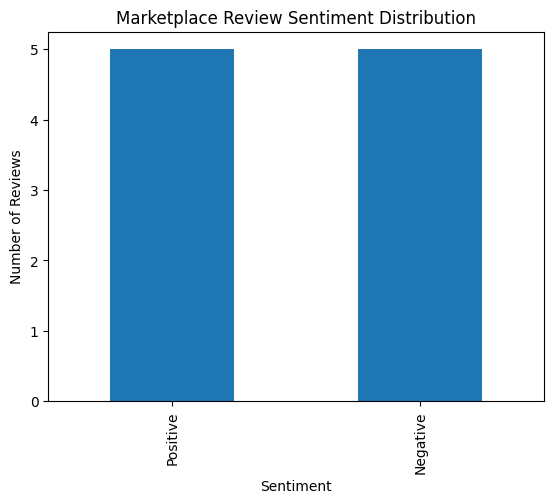

Model Accuracy: 0.0


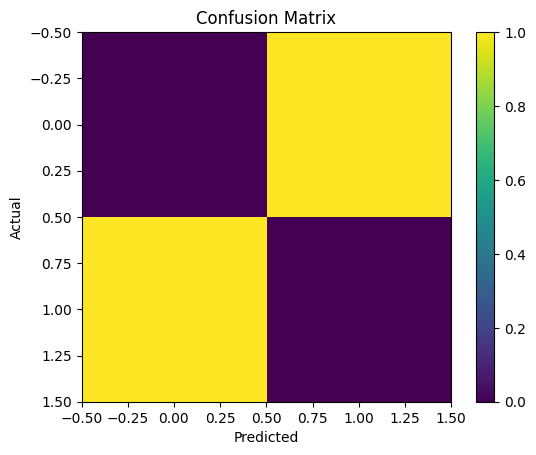

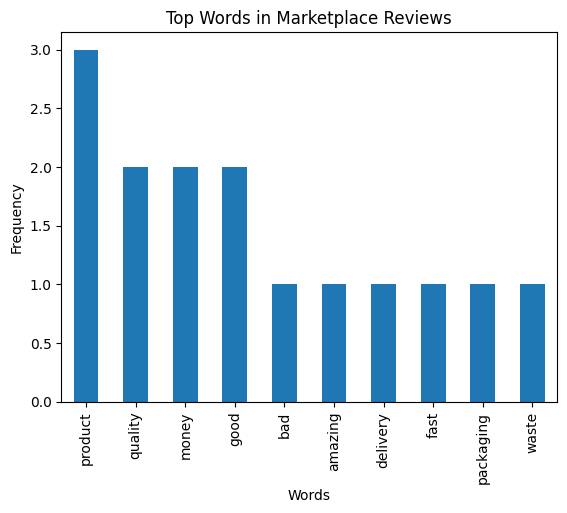

Review: product good
Prediction: Positive
Review: poor quality waste
Prediction: Negative


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

nltk.download('stopwords')

# Sample Marketplace Dataset
data = {
    "review":[
        "This product is amazing",
        "Very bad quality",
        "Fast delivery and good packaging",
        "Waste of money",
        "Excellent product quality",
        "Very disappointing product",
        "Highly recommended",
        "Worst purchase ever",
        "Good value for money",
        "Not worth buying"
    ],

    "sentiment":[
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative"
    ]
}

df = pd.DataFrame(data)

# Graph 1 : Sentiment Distribution
sentiment_count = df["sentiment"].value_counts()

plt.figure()
sentiment_count.plot(kind='bar')
plt.title("Marketplace Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

# Text Cleaning
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)

# TF-IDF Feature Extraction
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["clean_review"])
y = df["sentiment"]

# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# Train Model
model = LogisticRegression()
model.fit(X_train,y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Model Accuracy:",accuracy_score(y_test,y_pred))

# Graph 2 : Confusion Matrix
cm = confusion_matrix(y_test,y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# Graph 3 : Word Frequency
all_words = " ".join(df["clean_review"])
words = all_words.split()

word_freq = pd.Series(words).value_counts().head(10)

plt.figure()
word_freq.plot(kind='bar')
plt.title("Top Words in Marketplace Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

# Predict New Review
def predict_review(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)

    print("Review:",text)
    print("Prediction:",prediction[0])

predict_review("This product is very good")
predict_review("Very poor quality and waste")